# Day 3 — MIT-BIH preprocessing validation

This notebook displays raw and filtered examples, checks beat-window alignment and normalization, and visualizes available source classes. It does not train a model or create splits. Filter parameters and unresolved choices are described in `docs/preprocessing.md`.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import wfdb
ROOT = Path.cwd()
if not (ROOT / 'configs/preprocessing/mitbih_v1.json').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.preprocessing.config import load_config
from src.preprocessing.filtering import filter_signal
from src.preprocessing.storage import load_record
from src.preprocessing.validation import validate_batch
cfg = load_config(ROOT / 'configs/preprocessing/mitbih_v1.json')
processed = ROOT / 'data/processed/mitbih_v1'
print('Config:', cfg.source, '| output:', processed)

Config: C:\Users\adni\Desktop\AI_Software_Engineering_Projects\blockchain-fl-arrhythmia-checkout\configs\preprocessing\mitbih_v1.json | output: C:\Users\adni\Desktop\AI_Software_Engineering_Projects\blockchain-fl-arrhythmia-checkout\data\processed\mitbih_v1


## Raw versus filtered signal
Record 100, channel 0, first ten seconds. Filtering is applied to the full continuous record before plotting.

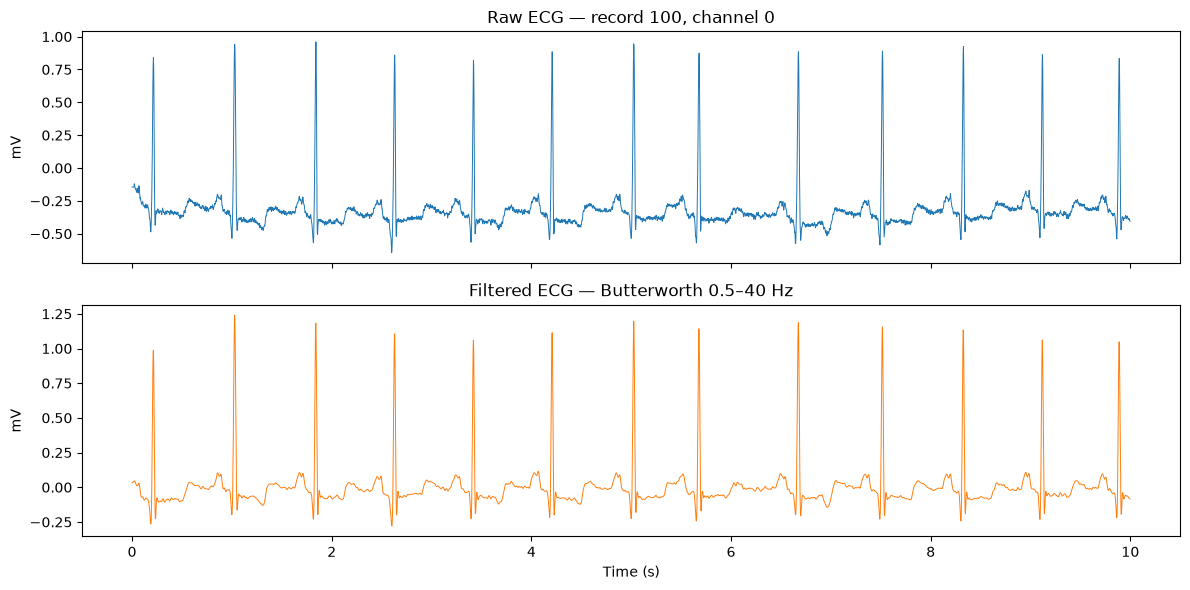

In [2]:
raw = wfdb.rdrecord(str(ROOT / 'data/raw/mitbih/100'), physical=True)
raw_signal = np.asarray(raw.p_signal, dtype=float)
filtered = filter_signal(raw_signal, raw.fs, cfg)
n = int(10 * raw.fs); time = np.arange(n) / raw.fs
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(time, raw_signal[:n, 0], lw=.7); ax[0].set_title('Raw ECG — record 100, channel 0'); ax[0].set_ylabel('mV')
ax[1].plot(time, filtered[:n, 0], lw=.7, color='tab:orange'); ax[1].set_title('Filtered ECG — Butterworth 0.5–40 Hz'); ax[1].set_ylabel('mV'); ax[1].set_xlabel('Time (s)')
fig.tight_layout(); plt.show()

## Segment, source annotation, and normalized waveform
Load the persisted record shard and check the associated label, annotation position, record and group metadata. The stored normalized sample at the annotation is index `pre_samples`.

{'labels': 'N', 'source_symbols': 'N', 'record_ids': '1', 'patient_groups': 'r', 'annotation_samples': 77, 'starts': 5, 'ends': 221}


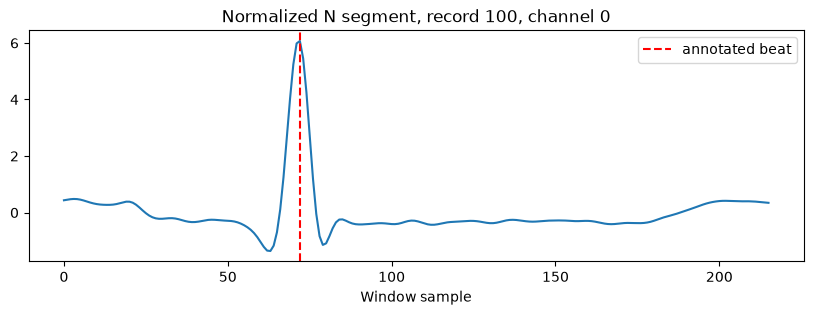

In [3]:
shard = load_record(processed / '100.npz')
idx = next(i for i, s in enumerate(shard['source_symbols']) if s == 'N')
window = shard['segments'][idx]; center = int(shard['annotation_samples'][idx]) - int(shard['starts'][idx])
assert window.shape == (cfg.segment_length, cfg.n_channels)
assert shard['labels'][idx] == cfg.labels[str(shard['source_symbols'][idx])]
assert center == cfg.pre and shard['ends'][idx] - shard['starts'][idx] == cfg.segment_length
assert np.isfinite(window).all()
assert np.allclose(window.mean(axis=0), 0, atol=2e-5) and np.allclose(window.std(axis=0), 1, atol=2e-5)
print({k: shard[k][idx].item() for k in ['labels','source_symbols','record_ids','patient_groups','annotation_samples','starts','ends']})
fig, ax = plt.subplots(figsize=(10, 3)); ax.plot(np.arange(len(window)), window[:, 0]); ax.axvline(center, color='red', ls='--', label='annotated beat'); ax.set_title('Normalized N segment, record 100, channel 0'); ax.set_xlabel('Window sample'); ax.legend(); plt.show()

## Representative examples from distinct observed classes
Classes are selected only when present in the processed shards. These are source labels, not a clinically merged target taxonomy.

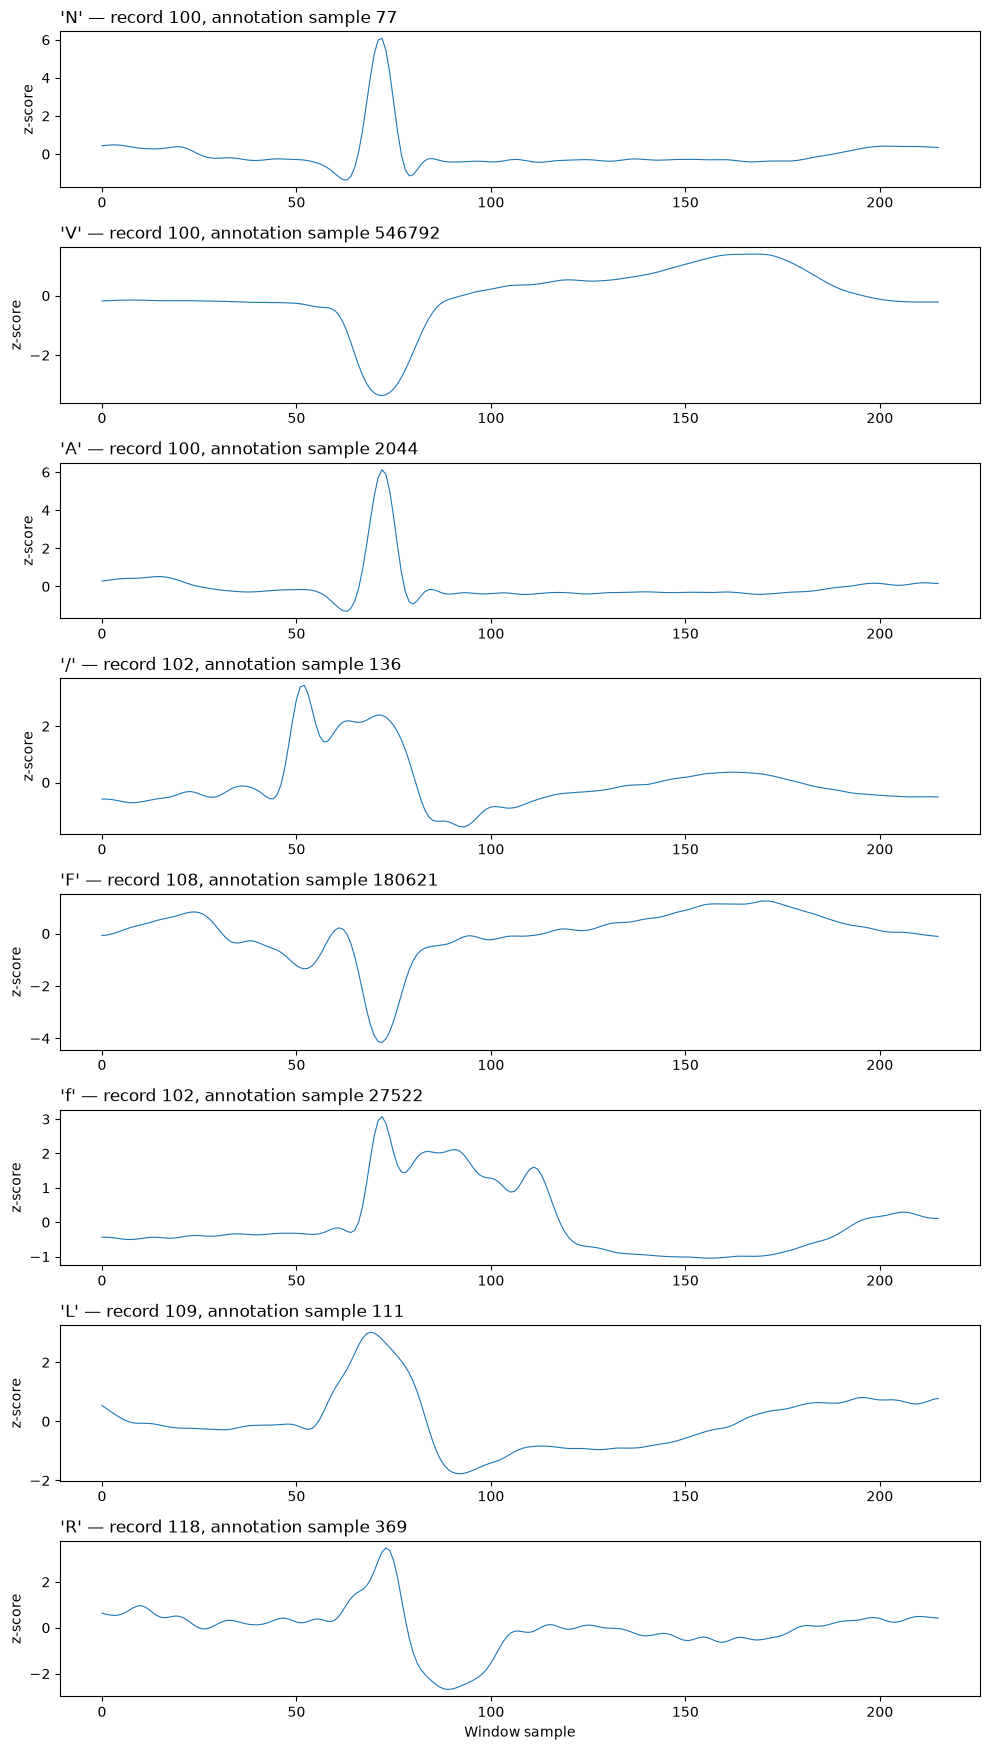

Shown source classes: ['N', 'V', 'A', '/', 'F', 'f', 'L', 'R']


In [4]:
examples = {}
for path in sorted(processed.glob('*.npz')):
    data = load_record(path)
    for i, label in enumerate(data['labels']):
        examples.setdefault(str(label), (path.stem, data, i))
        if len(examples) == len(cfg.labels): break
wanted = [x for x in ['N','V','A','/','F','f','L','R'] if x in examples]
fig, axes = plt.subplots(len(wanted), 1, figsize=(10, 2.2*len(wanted)), squeeze=False)
for ax, label in zip(axes[:, 0], wanted):
    rid, data, i = examples[label]; ax.plot(data['segments'][i, :, 0], lw=.8); ax.set_title(f'{label!r} — record {rid}, annotation sample {data["annotation_samples"][i]}', loc='left'); ax.set_ylabel('z-score')
axes[-1,0].set_xlabel('Window sample'); fig.tight_layout(); plt.show()
print('Shown source classes:', wanted)

## Dataset-wide integrity and class counts
Checks below verify shape, finite values, stored label-symbol identity, and alignment for every processed segment. Counts are descriptive and reflect edge-window exclusion.

Records: 48 | segments: 109460
{'/': 7027, 'A': 2546, 'E': 106, 'F': 802, 'J': 83, 'L': 8072, 'N': 75028, 'Q': 33, 'R': 7255, 'S': 2, 'V': 7129, 'a': 150, 'e': 16, 'f': 982, 'j': 229}


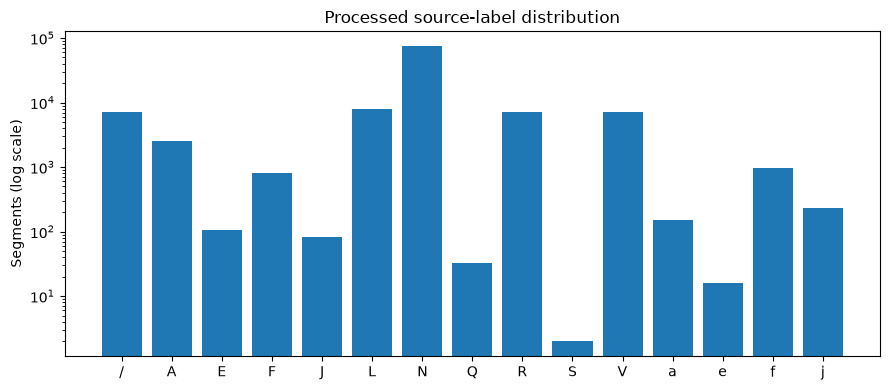

In [5]:
from collections import Counter
counts = Counter(); total = 0
for path in sorted(processed.glob('*.npz')):
    data = load_record(path); n = len(data['labels']); total += n
    assert data['segments'].shape == (n, cfg.segment_length, cfg.n_channels)
    assert np.isfinite(data['segments']).all()
    assert len(data['source_symbols']) == len(data['annotation_samples']) == len(data['starts']) == len(data['ends']) == n
    for i, symbol in enumerate(data['source_symbols']):
        assert cfg.labels[str(symbol)] == data['labels'][i]
        assert int(data['starts'][i]) + cfg.pre == int(data['annotation_samples'][i])
        assert int(data['ends'][i]) - cfg.post == int(data['annotation_samples'][i])
    counts.update(map(str, data['labels']))
assert (processed / 'manifest.json').exists()
print('Records:', len(list(processed.glob('*.npz'))), '| segments:', total)
print(dict(sorted(counts.items())))
fig, ax = plt.subplots(figsize=(9, 4)); labels = sorted(counts); ax.bar(labels, [counts[k] for k in labels]); ax.set_yscale('log'); ax.set_ylabel('Segments (log scale)'); ax.set_title('Processed source-label distribution'); fig.tight_layout(); fig.savefig(ROOT / 'results/figures/mitbih_preprocessing_class_distribution.png', dpi=160); plt.show()